In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root, so `src` imports work
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
from src import config

# 01 — Cleaning & Integration (Deliverable A)

Turns the three raw exports into one trustworthy, time-aligned, joined and feature-engineered
modelling table. Every number in `reports/A_cleaning_and_integration.md` is written by this notebook.

**One clock for everything:** Addis Ababa local time (EAT = UTC+3, no daylight saving). Every
`pickup_hour` below means *start of the hour in EAT*.

In [2]:
from src import cleaning, features, dictionary
from src.nbtools import Report
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

raw_train = pd.read_csv(config.RAW / "ride_demand_train.csv")
raw_test = pd.read_csv(config.RAW / "ride_demand_test.csv")
raw_weather = pd.read_csv(config.RAW / "weather_hourly.csv")
raw_events = pd.read_csv(config.RAW / "events_calendar.csv")
for n, d in [("train", raw_train), ("test", raw_test), ("weather", raw_weather), ("events", raw_events)]:
    print(f"{n:8s} {d.shape}")

R = Report("A — Data Cleaning & Integration Pipeline (team " + config.TEAM_NAME + ")")
R.p("Generated by `notebooks/01_cleaning_and_integration.ipynb` (code in `src/cleaning.py`, "
    "`src/features.py`). All timestamps are Addis Ababa local time (EAT, UTC+3).")

train    (85460, 7)
test     (4032, 3)
weather  (7538, 6)
events   (165, 9)


## Clean all three tables

In [3]:
log = cleaning.CleaningLog()
trips_clean = cleaning.clean_trips(raw_train, log)
train_grid = cleaning.build_trip_grid(trips_clean, log, len(raw_train))
test_clean = cleaning.clean_test(raw_test)
weather = cleaning.clean_weather(raw_weather, log)
events = cleaning.clean_events(raw_events, log)
print(train_grid["row_status"].value_counts())
print("weather hours:", len(weather), weather["pickup_hour"].min(), "->", weather["pickup_hour"].max())
print("events kept:", len(events), events["status"].value_counts().to_dict())

row_status
observed         83104
prelaunch         1752
missing_value     1510
random_gap         682
outage             504
Name: count, dtype: int64
weather hours: 7656 2024-12-31 00:00:00 -> 2025-11-14 23:00:00
events kept: 159 {'confirmed': 153, 'cancelled': 6}


## A1 — Cleaning log

In [4]:
cl = log.frame()
counts = cl.groupby("file").size()
print(counts)
assert counts["ride_demand_train.csv"] >= 5 and counts["weather_hourly.csv"] >= 4 and counts["events_calendar.csv"] >= 4
cl.to_csv(config.REPORTS / "A1_cleaning_log.csv", index=False)
R.h("A1 Cleaning log")
R.p(f"{len(cl)} issues: {counts['ride_demand_train.csv']} in the trip file, "
    f"{counts['weather_hourly.csv']} in the weather file, {counts['events_calendar.csv']} in the events "
    "file. Row counts are against the raw file (weather/event grid rows against the cleaned grid). "
    "Also saved as `reports/A1_cleaning_log.csv`.")
R.table(cl)
cl

file
events_calendar.csv       9
ride_demand_train.csv    11
weather_hourly.csv        8
dtype: int64


,file,columns,issue_type,rows_affected,pct_rows,fix_applied,why
0,ride_demand_train.csv,zone,"inconsistent zone spelling (55 variants: case,...",32391,37.90,mapped to 12 canonical labels via an explicit ...,zone is the join key to weather/events and the...
1,ride_demand_train.csv,pickup_hour,"3 timestamp formats (YYYY-MM-DD HH:MM, DD/MM/Y...",38574,45.14,parsed each format with an explicit format str...,inferred parsing would read day-first dates as...
2,ride_demand_train.csv,trips,sentinel value -1 (impossible for a count/dura...,681,0.80,set to missing,-1 is a 'no reading' code; keeping it biases m...
3,ride_demand_train.csv,avg_wait_min,sentinel value -1 (impossible for a count/dura...,1707,2.00,set to missing,-1 is a 'no reading' code; keeping it biases m...
4,ride_demand_train.csv,trips,blank target,845,0.99,kept as a missing zone-hour in the grid; exclu...,imputing the target would invent training labels
5,ride_demand_train.csv,avg_fare_birr,blank fare,1277,1.49,left missing; zone medians used where a fare i...,"fare is analysis-only, never a model input"
6,ride_demand_train.csv,trips,inflated counts: trips/active_drivers >= 4.0 (...,125,0.15,divided by 8 (restores ~1.3 trips per driver),"drivers, wait and fare stay normal on these ro..."
7,ride_demand_train.csv,"zone, pickup_hour",duplicate zone-hour keys (same hour written in...,1692,1.98,collapsed to one row per zone-hour: mean of va...,480 rows were exact copies; the rest differ by...
8,ride_demand_train.csv,(rows),zone not launched yet (Ayat starts 15 Mar 2025),1752,2.00,kept in grid as status 'prelaunch'; excluded f...,zero demand before launch is not a demand pattern
9,ride_demand_train.csv,(rows),platform outage: no zone has data 12 May 02:00...,504,0.58,kept in grid as status 'outage'; excluded from...,"missing because the platform was down, not bec..."


## A2 — Time & key standardization
### A2a Zone and event-type labels before/after

In [5]:
def before_after(raw_values, mapper):
    t = pd.Series(raw_values).value_counts().rename_axis("raw").reset_index(name="rows")
    t["cleaned"] = t["raw"].map(mapper)
    t["raw"] = t["raw"].map(repr)  # repr shows trailing spaces
    return t.sort_values(["cleaned", "raw"])[["raw", "rows", "cleaned"]]

zone_trips = before_after(raw_train["zone"], cleaning.canonical_zone)
zone_test = before_after(raw_test["zone"], cleaning.canonical_zone)
zone_events = before_after(raw_events["zone"], lambda z: ", ".join(cleaning.event_zones(z)) if len(cleaning.event_zones(z)) < 12 else "ALL 12 zones")
etype = before_after(raw_events["event_type"], cleaning.canonical_event_type)
summary = pd.DataFrame({
    "table / column": ["train.zone", "test.zone", "events.zone", "events.event_type"],
    "unique raw values": [raw_train["zone"].nunique(), raw_test["zone"].nunique(),
                          raw_events["zone"].nunique(), raw_events["event_type"].nunique()],
    "unique cleaned values": [train_grid["zone"].nunique(), test_clean["zone"].nunique(),
                              len(set(z for zs in events["zones"] for z in zs)), events["event_type"].nunique()],
})
print(summary)
assert set(train_grid["zone"]) == set(test_clean["zone"]) == set(config.ZONES)
assert set(z for zs in events["zones"] for z in zs) <= set(config.ZONES)

R.h("A2 Time & key standardization")
R.h("A2a Zone and event-type labels, before and after", 3)
R.p("All three tables end with the same 12 zone labels: " + ", ".join(config.ZONES) + ". "
    "Raw values are shown with `repr` so trailing spaces are visible.")
R.table(summary)
for title, t in [("Trip file zone", zone_trips), ("Test file zone", zone_test),
                 ("Events zone (multi-zone and city-wide rows expand to several zones)", zone_events),
                 ("Events event_type", etype)]:
    R.p(f"**{title}**")
    R.table(t)
summary

      table / column  unique raw values  unique cleaned values
0         train.zone                 55                     12
1          test.zone                 55                     12
2        events.zone                 28                     12
3  events.event_type                 20                      8


,table / column,unique raw values,unique cleaned values
0,train.zone,55,12
1,test.zone,55,12
2,events.zone,28,12
3,events.event_type,20,8


### A2b Timestamp formats and round-trip proof

In [6]:
def round_trip(raw, parsed, fmt):
    back = {"ymd_hm": parsed.dt.strftime("%Y-%m-%d %H:%M"),
            "dmy_hm": parsed.dt.strftime("%d/%m/%Y %H:%M"),
            "iso_offset": parsed.dt.strftime("%Y-%m-%dT%H:%M:%S") + "+03:00",
            "iso_z": (parsed).dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "mon_d_y_ampm": parsed.dt.strftime("%b %d, %Y %I:%M %p")}
    out = pd.Series(False, index=raw.index)
    for k, v in back.items():
        m = fmt == k
        out[m] = (v[m] == raw[m])
    return out

rows = []
t_tr, f_tr = cleaning.parse_trip_hours(raw_train["pickup_hour"])
t_te, f_te = cleaning.parse_trip_hours(raw_test["pickup_hour"])
t_w, f_w = cleaning.parse_weather_raw_clock(raw_weather["timestamp"])
t_s, f_s = cleaning.parse_event_times(raw_events["start_datetime"])
t_e, f_e = cleaning.parse_event_times(raw_events["end_datetime"])
examples = {"ymd_hm": "%Y-%m-%d %H:%M", "dmy_hm": "%d/%m/%Y %H:%M (day-first)",
            "iso_offset": "%Y-%m-%dT%H:%M:%S%z -> converted to EAT", "iso_z": "%Y-%m-%dT%H:%M:%SZ",
            "mon_d_y_ampm": "%b %d, %Y %I:%M %p", "missing": "(blank)"}
for table, raw_s, t, f in [("train.pickup_hour", raw_train["pickup_hour"], t_tr, f_tr),
                           ("test.pickup_hour", raw_test["pickup_hour"], t_te, f_te),
                           ("weather.timestamp", raw_weather["timestamp"], t_w, f_w),
                           ("events.start_datetime", raw_events["start_datetime"], t_s, f_s),
                           ("events.end_datetime", raw_events["end_datetime"], t_e, f_e)]:
    rt = round_trip(raw_s.fillna(""), t, f)
    for k, g in f.groupby(f):
        idx = g.index
        rows.append({"column": table, "format": k, "parse rule": examples[k], "rows": len(idx),
                     "example raw": raw_s[idx[0]], "parsed": t[idx[0]],
                     "unparsed": int(t[idx].isna().sum()) if k != "missing" else 0,
                     "round-trip equal": "n/a" if k == "missing" else f"{rt[idx].mean():.0%}"})
fmt_table = pd.DataFrame(rows)
dayfirst = pd.DataFrame([dict(column=c, **cleaning.day_first_check(s)) for c, s in
                         [("train.pickup_hour", raw_train["pickup_hour"]), ("test.pickup_hour", raw_test["pickup_hour"]),
                          ("weather.timestamp", raw_weather["timestamp"]),
                          ("events.start_datetime", raw_events["start_datetime"]),
                          ("events.end_datetime", raw_events["end_datetime"])]])
assert (dayfirst["second_field_gt_12"] == 0).all()
print(fmt_table.to_string()); print(dayfirst)

R.h("A2b Timestamp formats", 3)
R.p("Every format is matched by a regular expression and parsed with an explicit `format=` string "
    "(never inferred). *Round-trip equal* re-formats each parsed timestamp with the same pattern "
    "and compares it to the raw text: 100% everywhere means nothing was misread "
    "(for ISO `+03:00` the parsed value is already EAT, so it round-trips to the same text).")
R.table(fmt_table)
R.p("**Day-first proof.** In every slash-formatted column many rows have a first field above 12 "
    "(impossible for a month) and no row has a second field above 12 (which month-first data would "
    "need), so `dd/mm/yyyy` is the only consistent reading.")
R.table(dayfirst)
fmt_table

                   column        format                               parse rule   rows                example raw              parsed  unparsed round-trip equal
0       train.pickup_hour        dmy_hm               %d/%m/%Y %H:%M (day-first)  25764           16/08/2025 04:00 2025-08-16 04:00:00         0             100%
1       train.pickup_hour    iso_offset  %Y-%m-%dT%H:%M:%S%z -> converted to EAT  12810  2025-05-27T23:00:00+03:00 2025-05-27 23:00:00         0             100%
2       train.pickup_hour        ymd_hm                           %Y-%m-%d %H:%M  46886           2025-06-26 11:00 2025-06-26 11:00:00         0             100%
3        test.pickup_hour        dmy_hm               %d/%m/%Y %H:%M (day-first)   1198           05/11/2025 14:00 2025-11-05 14:00:00         0             100%
4        test.pickup_hour    iso_offset  %Y-%m-%dT%H:%M:%S%z -> converted to EAT    573  2025-11-03T20:00:00+03:00 2025-11-03 20:00:00         0             100%
5        test.pickup_hour   

,column,format,parse rule,rows,example raw,parsed,unparsed,round-trip equal
0,train.pickup_hour,dmy_hm,%d/%m/%Y %H:%M (day-first),25764,16/08/2025 04:00,2025-08-16 04:00:00,0,100%
1,train.pickup_hour,iso_offset,%Y-%m-%dT%H:%M:%S%z -> converted to EAT,12810,2025-05-27T23:00:00+03:00,2025-05-27 23:00:00,0,100%
2,train.pickup_hour,ymd_hm,%Y-%m-%d %H:%M,46886,2025-06-26 11:00,2025-06-26 11:00:00,0,100%
3,test.pickup_hour,dmy_hm,%d/%m/%Y %H:%M (day-first),1198,05/11/2025 14:00,2025-11-05 14:00:00,0,100%
4,test.pickup_hour,iso_offset,%Y-%m-%dT%H:%M:%S%z -> converted to EAT,573,2025-11-03T20:00:00+03:00,2025-11-03 20:00:00,0,100%
5,test.pickup_hour,ymd_hm,%Y-%m-%d %H:%M,2261,2025-11-05 18:00,2025-11-05 18:00:00,0,100%
6,weather.timestamp,dmy_hm,%d/%m/%Y %H:%M (day-first),732,31/12/2024 15:00,2024-12-31 15:00:00,0,100%
7,weather.timestamp,iso_z,%Y-%m-%dT%H:%M:%SZ,6806,2024-12-30T21:00:00Z,2024-12-30 21:00:00,0,100%
8,events.start_datetime,dmy_hm,%d/%m/%Y %H:%M (day-first),50,06/02/2025 18:00,2025-02-06 18:00:00,0,100%
9,events.start_datetime,mon_d_y_ampm,"%b %d, %Y %I:%M %p",36,"May 14, 2025 01:00 PM",2025-05-14 13:00:00,0,100%


### A2c Which clock is each table on? (time-zone proof)

In [7]:
ev = cleaning.weather_clock_evidence(raw_weather)
prof = ev["temp_profile_by_format"]
# Does the dd/mm/yyyy subset sit on the same clock as the 'Z' subset? Compare the curves at shifts.
shift_corr = pd.Series({s: np.corrcoef(prof["iso_z"].values, np.roll(prof["dmy_hm"].values, -s))[0, 1]
                        for s in range(-5, 6)}, name="corr")
best_shift = int(shift_corr.idxmax())
# Trips: the ISO rows carry +03:00, and the plain formats agree with them on the same zone-hours.
iso = raw_train.assign(t=t_tr, f=f_tr, zone_c=raw_train["zone"].map(cleaning.canonical_zone))
pairs = iso[iso.f == "iso_offset"].merge(iso[iso.f != "iso_offset"], on=["zone_c", "t"], suffixes=("_iso", "_plain"))
same_trips = (pairs["active_drivers_iso"] == pairs["active_drivers_plain"]).mean()
clock = pd.DataFrame([
    ["trips (train/test)", "EAT", f"ISO rows carry '+03:00' ({(f_tr=='iso_offset').sum():,} train / {(f_te=='iso_offset').sum():,} test); "
     f"{len(pairs):,} zone-hours appear both as ISO and as a plain format, and {same_trips:.0%} of those pairs have identical active_drivers -> plain formats are EAT too", "none"],
    ["weather", "UTC", f"first raw row {ev['first_row_raw']:%d %b %Y %H:%M}, last {ev['last_row_raw']:%d %b %Y %H:%M}; "
     f"first forecast row {ev['first_forecast_raw']:%d %b %H:%M} raw = 1 Nov 00:00 EAT only if the raw clock is UTC; "
     f"temperature peaks at {ev['temp_peak_hour_raw_iso_z']}:00 raw = {ev['temp_peak_hour_raw_iso_z']+3}:00 EAT (mid-afternoon); "
     f"dd/mm/yyyy rows best match the 'Z' rows at shift {best_shift} h (r = {shift_corr.max():.3f})", "+3 h on every row"],
    ["events", "EAT", "holidays run 00:00-23:59 and football matches start 15:00-19:00 local; "
     "documented as local time", "none"],
], columns=["table", "clock", "evidence from the data", "conversion applied"])
print(clock.to_string())
assert ev["first_forecast_raw"] + pd.Timedelta(hours=3) == pd.Timestamp(config.TEST_START)
assert best_shift == 0

R.h("A2c Clock of each table and the conversion", 3)
R.table(clock)
R.p(f"**Conclusion.** The weather export is on UTC — including the {(f_w=='dmy_hm').sum()} rows written "
    "without a 'Z'. The decisive evidence is the forecast boundary: forecasts must start at the first "
    f"forecast hour, 1 Nov 00:00 EAT, and the first forecast row is stamped {ev['first_forecast_raw']:%d %b %H:%M}, "
    "exactly 3 hours earlier. We add 3 hours to every weather timestamp. B2.1 shows the same answer "
    "from the rain–demand relationship.")
R.table(prof.round(1).rename(columns={"iso_z": "mean temp, 'Z' rows", "dmy_hm": "mean temp, dd/mm rows"}).rename_axis("raw hour"), index=True)
clock

                table clock                                                                                                                                                                                                                                                     evidence from the data conversion applied
0  trips (train/test)   EAT                                                                             ISO rows carry '+03:00' (12,810 train / 573 test); 214 zone-hours appear both as ISO and as a plain format, and 100% of those pairs have identical active_drivers -> plain formats are EAT too               none
1             weather   UTC  first raw row 30 Dec 2024 21:00, last 14 Nov 2025 20:00; first forecast row 31 Oct 21:00 raw = 1 Nov 00:00 EAT only if the raw clock is UTC; temperature peaks at 12:00 raw = 15:00 EAT (mid-afternoon); dd/mm/yyyy rows best match the 'Z' rows at shift 0 h (r = 0.996)  +3 h on every row
2              events   EAT                               

,table,clock,evidence from the data,conversion applied
0,trips (train/test),EAT,"ISO rows carry '+03:00' (12,810 train / 573 te...",none
1,weather,UTC,"first raw row 30 Dec 2024 21:00, last 14 Nov 2...",+3 h on every row
2,events,EAT,holidays run 00:00-23:59 and football matches ...,none


## Joins + features (A3–A6)

In [8]:
res = features.build_masters(train_grid, test_clean, weather, events)
master_train, master_test, audits = res["master_train"], res["master_test"], res["audits"]
print(res["zone_types"])
print(master_train.shape, master_test.shape)

Arat Kilo    business_district
Ayat               residential
Bole         nightlife_airport
CMC                residential
Gerji              residential
Kazanchis    business_district
Kolfe              residential
Lideta           transport_hub
Megenagna        transport_hub
Merkato                 market
Piassa       business_district
Sarbet             residential
Name: zone_type, dtype: str
(87552, 49) (4032, 44)


## A3 — Join map

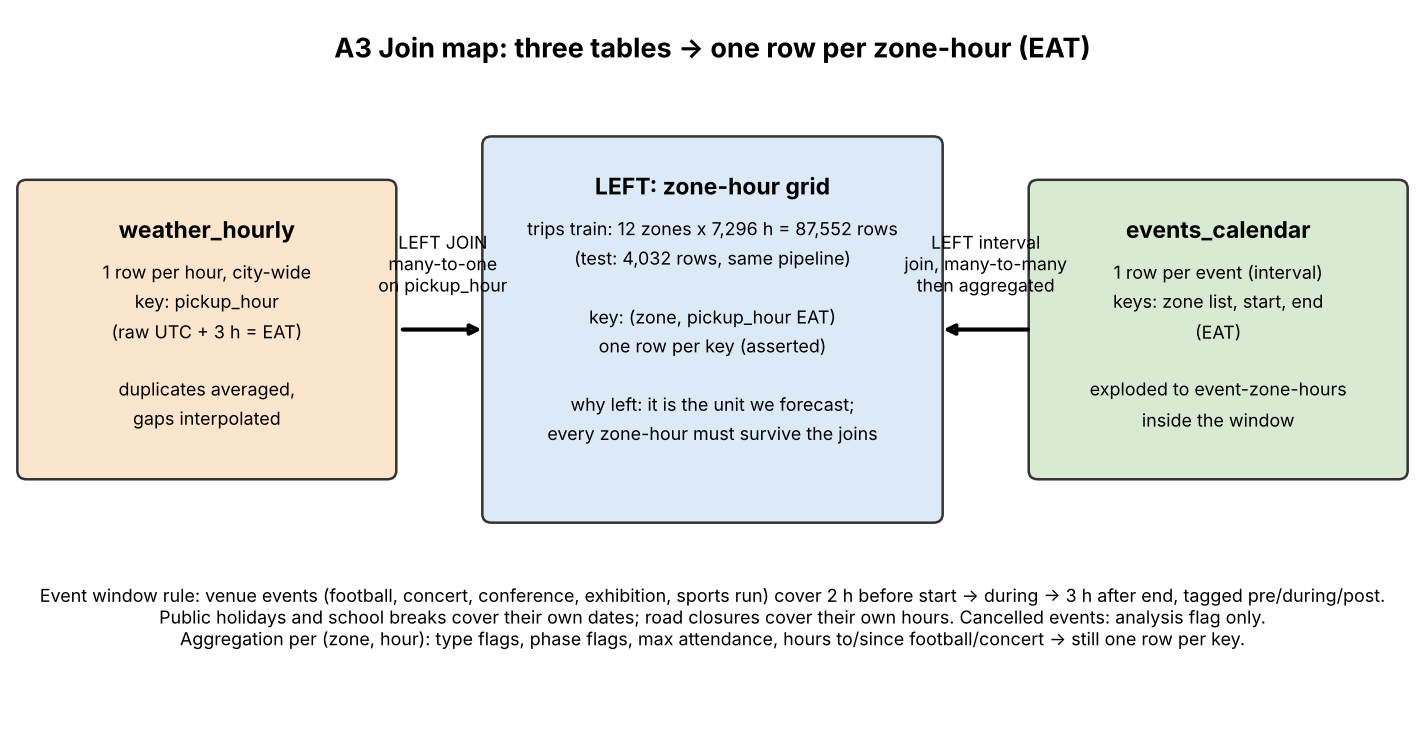

In [9]:
fig, ax = plt.subplots(figsize=(12, 6.2), dpi=150)
ax.set_xlim(0, 12); ax.set_ylim(0, 6.6); ax.axis("off")
def box(x, y, w, h, title, body, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08", fc=color, ec="#333", lw=1.2))
    ax.text(x + w / 2, y + h - 0.25, title, ha="center", va="top", fontsize=11, fontweight="bold")
    ax.text(x + w / 2, y + h - 0.65, body, ha="center", va="top", fontsize=8.6, linespacing=1.35)
box(4.1, 2.0, 3.8, 3.4, "LEFT: zone-hour grid",
    "trips train: 12 zones x 7,296 h = 87,552 rows\n(test: 4,032 rows, same pipeline)\n\nkey: (zone, pickup_hour EAT)\none row per key (asserted)\n\nwhy left: it is the unit we forecast;\nevery zone-hour must survive the joins", "#DCEAF7")
box(0.1, 2.4, 3.1, 2.6, "weather_hourly",
    "1 row per hour, city-wide\nkey: pickup_hour\n(raw UTC + 3 h = EAT)\n\nduplicates averaged,\ngaps interpolated", "#FCE5CD")
box(8.8, 2.4, 3.1, 2.6, "events_calendar",
    "1 row per event (interval)\nkeys: zone list, start, end\n(EAT)\n\nexploded to event-zone-hours\ninside the window", "#D9EAD3")
ax.annotate("", xy=(4.05, 3.7), xytext=(3.3, 3.7), arrowprops=dict(arrowstyle="-|>", lw=2))
ax.text(3.68, 4.05, "LEFT JOIN\nmany-to-one\non pickup_hour", ha="center", fontsize=8.5)
ax.annotate("", xy=(7.95, 3.7), xytext=(8.75, 3.7), arrowprops=dict(arrowstyle="-|>", lw=2))
ax.text(8.35, 4.05, "LEFT interval\njoin, many-to-many\nthen aggregated", ha="center", fontsize=8.5)
ax.text(6.0, 1.35, f"Event window rule: venue events (football, concert, conference, exhibition, sports run) cover "
        f"{config.EVENT_PRE_HOURS} h before start -> during -> {config.EVENT_POST_HOURS} h after end, tagged pre/during/post.\n"
        "Public holidays and school breaks cover their own dates; road closures cover their own hours. "
        "Cancelled events: analysis flag only.\n"
        "Aggregation per (zone, hour): type flags, phase flags, max attendance, hours to/since football/concert -> still one row per key.",
        ha="center", va="top", fontsize=8.6, wrap=True)
ax.text(6.0, 6.45, "A3 Join map: three tables -> one row per zone-hour (EAT)", ha="center", va="top", fontsize=13, fontweight="bold")
fig.savefig(config.REPORTS / "a3_join_map.png", bbox_inches="tight")
plt.show()

R.h("A3 Join map")
R.img("a3_join_map.png", "Join map")
R.p("* **Left table = the zone-hour grid** (train: every zone x every hour 1 Jan–31 Oct; test: the 4,032 "
    "test rows). It is the unit we forecast, so every zone-hour must survive the joins — including "
    "outage/missing hours, which keep a status flag rather than disappearing.\n"
    "* **Weather: left join, many-to-one on `pickup_hour`** after shifting weather from UTC to EAT. "
    "The weather key is made unique first (duplicate hours averaged), so the row count cannot change.\n"
    "* **Events: interval join.** Each event is expanded to (event, zone, hour) rows covering its window, "
    f"then aggregated back to one row per (zone, hour). Window rule: venue events reach {config.EVENT_PRE_HOURS} h before "
    f"the start (arrivals) and {config.EVENT_POST_HOURS} h after the end (the departing crowd; the length is checked in A6b). "
    "Holidays and school breaks are day-level calendar items; road closures only cover their own hours.")

## A4 — Join audit

In [10]:
wa = pd.DataFrame({k: audits[k] for k in ["weather_train", "weather_test"]}).T.astype(float)
wa = wa.astype({c: int for c in wa.columns if c != "match_rate_pct"})
ea = pd.DataFrame({k: {kk: (len(vv) if isinstance(vv, list) else vv) for kk, vv in audits[k].items()} for k in ["events_train", "events_test"]}).T
print(wa); print(ea)
imp = master_train.groupby("weather_imputed").size()
w_imp_reason = weather[weather["weather_imputed"]]
n_missing_hours = int(raw_weather.shape[0])
cancelled = events[events.status == "cancelled"]
unmatched_train = [e for e in audits["events_train"]["events_unmatched"]]
um = events[events.event_id.isin(unmatched_train)][["event_id", "event_type", "start", "status"]]
excluded = pd.DataFrame({
    "reason": ["duplicate of another row (dropped in cleaning)", "cancelled (kept only as analysis flag)",
               "starts after 31 Oct (only reaches the test fortnight)"],
    "events": [int(len(raw_events) - len(events)), len(cancelled),
               int((events.start > pd.Timestamp(config.TRAIN_END)).sum())]})
print(excluded)

R.h("A4 Join audit")
R.p("**Weather join (many-to-one on EAT hour)**")
R.table(wa.reset_index().rename(columns={"index": "join"}))
w_raw_t = cleaning.parse_weather_raw_clock(raw_weather["timestamp"])[0]
n_dup_hours = int(w_raw_t[w_raw_t.duplicated(keep=False)].nunique())
n_gap_hours = len(pd.date_range(w_raw_t.min(), w_raw_t.max(), freq="h").difference(w_raw_t))
R.p(f"Row counts are unchanged ({audits['weather_train']['rows_before']:,} -> {audits['weather_train']['rows_after']:,} train, "
    f"{audits['weather_test']['rows_before']:,} -> {audits['weather_test']['rows_after']:,} test) because weather keys were made unique before "
    f"joining. Without that step, {n_dup_hours} duplicated weather hours would have duplicated their zone-hours "
    f"(a many-to-many join) and {n_gap_hours} missing hours "
    "would have left zone-hours without weather. After reindexing + interpolation every zone-hour has weather "
    f"(match rate 100%); {audits['weather_train']['matched_to_imputed_weather_hour']:,} train and "
    f"{audits['weather_test']['matched_to_imputed_weather_hour']:,} test zone-hours use an interpolated hour "
    "(a gap, a blank value or a -9999 sentinel) and carry `weather_imputed = True`.")
R.p("**Events join (interval join on zone + hour)**")
R.table(ea.reset_index().rename(columns={"index": "join"}))
R.p(f"Of {len(events)} cleaned events, {audits['events_train']['events_matched_any_zone_hour']} touch at least one training zone-hour "
    f"({audits['events_train']['events_matched_confirmed']} of them confirmed) and {audits['events_test']['events_matched_any_zone_hour']} touch the test fortnight. "
    f"Excluded or unmatched:")
R.table(excluded)
R.p("Cancelled events are not model features (they did not happen); B3.4 tests whether they left any footprint.")
ea

               rows_before  rows_after  matched  match_rate_pct  matched_to_imputed_weather_hour  unmatched
weather_train        87552       87552    87552           100.0                             5280          0
weather_test          4032        4032     4032           100.0                              180          0
              rows_before  rows_after  zone_hours_in_any_confirmed_window  events_total  events_matched_any_zone_hour  events_matched_confirmed  events_unmatched
events_train        87552       87552                               24809           159                           152                       146                 7
events_test          4032        4032                                  66           159                             7                         7               152
                                              reason  events
0     duplicate of another row (dropped in cleaning)       6
1             cancelled (kept only as analysis flag)       6
2  star

,rows_before,rows_after,zone_hours_in_any_confirmed_window,events_total,events_matched_any_zone_hour,events_matched_confirmed,events_unmatched
events_train,87552,87552,24809,159,152,146,7
events_test,4032,4032,66,159,7,7,152


## A5 — Join proof: three zone-hours

In [11]:
mt = master_train[master_train.row_status == "observed"]
rainy = mt.sort_values(["rain_mm", "zone"], ascending=[False, True]).iloc[0]
fb = events[(events.event_type == "football_match") & (events.status == "confirmed")
            & (events.start < pd.Timestamp(config.TRAIN_END))].sort_values("attendance", ascending=False).iloc[0]
in_ev = mt[(mt.zone == fb.zones[0]) & (mt.pickup_hour == fb.end.floor("h"))].iloc[0]
hol = events[(events.event_type == "public_holiday") & (events.event_name.str.startswith("Meskel"))].iloc[0]
holrow = mt[(mt.zone == "Merkato") & (mt.pickup_hour == hol.start + pd.Timedelta(hours=12))].iloc[0]

show_cols = ["zone", "pickup_hour", "trips", "temp_c", "rain_mm", "rain_3h", "rain_class", "is_public_holiday",
             "ev_football_window", "ev_pre", "ev_during", "ev_post", "ev_log_attendance",
             "ev_hours_to_major_start", "ev_hours_since_major_end", "ev_ids"]
R.h("A5 Join proof")
eh = res["event_hours"]
for label, row in [("Rain-affected zone-hour", rainy), ("Inside a football event window", in_ev), ("Public holiday", holrow)]:
    raw_ts = row.pickup_hour - pd.Timedelta(hours=3)
    w_raw = raw_weather[cleaning.parse_weather_raw_clock(raw_weather["timestamp"])[0] == raw_ts]
    e_rows = eh[(eh.zone == row.zone) & (eh.pickup_hour == row.pickup_hour)].merge(
        events[["event_id", "event_name", "start", "end"]], on="event_id")
    R.h(f"{label}: {row.zone}, {row.pickup_hour:%a %d %b %Y %H:%M} EAT", 3)
    R.p(f"Weather row attached (raw UTC stamp {raw_ts:%Y-%m-%d %H:%M} = {row.pickup_hour:%H:%M} EAT):")
    R.table(w_raw)
    R.p("Event rows attached (window phase per event):" if len(e_rows) else "Event rows attached: none.")
    if len(e_rows):
        R.table(e_rows[["event_id", "event_name", "event_type", "start", "end", "phase", "attendance", "status"]])
    R.p("Resulting master-table values:")
    R.table(row[show_cols].to_frame("value").T)
    print(label, row.zone, row.pickup_hour); display(row[show_cols].to_frame().T)

Rain-affected zone-hour Arat Kilo 2025-05-02 17:00:00


,zone,pickup_hour,trips,temp_c,rain_mm,rain_3h,rain_class,is_public_holiday,ev_football_window,ev_pre,ev_during,ev_post,ev_log_attendance,ev_hours_to_major_start,ev_hours_since_major_end,ev_ids
2921,Arat Kilo,2025-05-02 17:00:00,96.0,21.5,21.0,21.8,3,0.0,0.0,0.0,0.0,0.0,0.0,12.0,12.0,


Inside a football event window Kazanchis 2025-01-26 17:00:00


,zone,pickup_hour,trips,temp_c,rain_mm,rain_3h,rain_class,is_public_holiday,ev_football_window,ev_pre,ev_during,ev_post,ev_log_attendance,ev_hours_to_major_start,ev_hours_since_major_end,ev_ids
37097,Kazanchis,2025-01-26 17:00:00,55.0,21.3,0.0,0.0,0,0.0,1.0,0.0,0.0,1.0,10.456136,12.0,1.0,EVT-0007


Public holiday Merkato 2025-09-27 12:00:00


,zone,pickup_hour,trips,temp_c,rain_mm,rain_3h,rain_class,is_public_holiday,ev_football_window,ev_pre,ev_during,ev_post,ev_log_attendance,ev_hours_to_major_start,ev_hours_since_major_end,ev_ids
72132,Merkato,2025-09-27 12:00:00,54.0,20.3,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0,12.0,12.0,EVT-0126


## A6 — Feature table

In [12]:
ft = dictionary.feature_table(features.ALL_FEATURES)
grp = {"calendar": features.CALENDAR_FEATURES + features.D8_FEATURES, "zone": features.ZONE_FEATURES, "weather": features.WEATHER_FEATURES,
       "events": features.EVENT_FEATURES, "lag / trend": features.LAG_FEATURES}
ft.insert(1, "family", ft["feature"].map({f: g for g, fs in grp.items() for f in fs}))
fam = ft.groupby("family").size()
print(fam)
assert fam["calendar"] >= 3 and fam["weather"] >= 2 and fam["events"] >= 3 and fam["lag / trend"] >= 1 and len(ft) >= 8
R.h("A6 Feature engineering table")
R.p(f"{len(ft)} engineered features: " + ", ".join(f"{v} {k}" for k, v in fam.items()) + ". "
    "Lags are at least 14 days old — the forecast horizon — so every one is known when the forecast "
    "for 1–14 November is made on 31 October. Fitted pieces (zone types, the zone x weekday x hour "
    "profile, attendance medians) are learned on training rows only.")
R.table(ft)
ft

family
calendar       10
events         12
lag / trend     6
weather         6
zone            2
dtype: int64


,feature,family,group,formula,description,why_it_should_help,known_at_forecast_time
0,hour,calendar,calendar,pickup_hour.hour,Hour of day 0-23,demand has strong commuter/market/nightlife ho...,yes
1,dow,calendar,calendar,pickup_hour.dayofweek,"Day of week, 0 = Monday","business zones empty at weekends, nightlife zo...",yes
2,is_weekend,calendar,calendar,dow >= 5,1 on Saturday/Sunday,"same as dow, simpler split",yes
3,month,calendar,calendar,pickup_hour.month,Month 1-12,seasonal level shifts,yes
4,day_of_month,calendar,calendar,pickup_hour.day,Day of month,pay-cycle effects,yes
5,is_payday_window,calendar,calendar,day > days_in_month - 5 or day <= 2,1 in the last 5 days or first 2 days of a month,more spending money around payday (B4.3),yes
6,is_public_holiday,calendar,events,"interval join, public_holiday rows",1 if a confirmed public holiday covers the hour,holidays change the whole day's pattern,yes
7,is_school_break,calendar,events,"interval join, school_break rows",1 inside a confirmed school break,fewer school runs,yes
8,trend_days,calendar,calendar,(pickup_hour - 2025-01-01) / 1 day,Days since 1 Jan 2025,city demand grows ~40% Jan-Oct (B1.4),yes
9,zone_code,zone,zone,index in config.ZONES,Integer code of the zone,zone levels differ 2x,yes


### A6b Checking the event window rule against the data

In [13]:
from src import analysis
o_chk = analysis.expected_demand(master_train.assign(ev_ids=master_train.ev_ids.fillna("")))
rows = {}
for t in ["football_match", "concert"]:
    es = analysis.event_study(o_chk, events, t, anchor="end", offsets=range(-2, 6))
    rows[t] = es["mean"].round(2)
win = pd.DataFrame(rows).rename_axis("hour vs. event end (0 = last hour of the event, 1 = first hour after)")
print(win)
R.h("A6b Event window check", 3)
R.p("Demand ratio (trips / normal hour of the same zone, weekday, hour and week) by hour relative to "
    "the event end. Concert demand is still about double normal in the 3rd hour after the end and is back "
    "to normal by the 4th; football is back to normal by the 3rd. We therefore use "
    f"{config.EVENT_PRE_HOURS} h before the start and {config.EVENT_POST_HOURS} h after the end as the window.")
R.table(win, index=True)
win

                                                    football_match  concert
hour vs. event end (0 = last hour of the event,...                         
-2                                                            1.73     1.06
-1                                                            1.38     1.02
 0                                                            1.35     1.05
 1                                                            2.49     1.83
 2                                                            2.15     1.87
 3                                                            1.12     1.77
 4                                                            1.06     0.95
 5                                                            1.03     1.01


,football_match,concert
"hour vs. event end (0 = last hour of the event, 1 = first hour after)",,
-2,1.73,1.06
-1,1.38,1.02
0,1.35,1.05
1,2.49,1.83
2,2.15,1.87
3,1.12,1.77
4,1.06,0.95
5,1.03,1.01


## A7 — Integrity checks

In [14]:
import io, contextlib
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    checks = features.validate(master_train, master_test, audits, raw_test)
print(buf.getvalue())
assert (checks.result == "PASS").all(), "integrity check failed"
R.h("A7 Integrity checks")
R.p(f"{len(checks)} automated checks (`features.validate`), all re-run every time this notebook runs. Printed output:")
R.code(buf.getvalue())

[PASS] train: one row per zone-hour (12 zones x 7,296 hours) (87,552 rows)
[PASS] test: 4,032 rows, row_ids unique and in original order (4,032 rows)
[PASS] test: no duplicate zone-hour keys
[PASS] only the 12 canonical zone labels
[PASS] timestamps on EAT and in expected range
[PASS] no negative or sentinel values left (trips, wait, rain) (min trips 0.0, min rain 0.0)
[PASS] temperature physically plausible (0-35 degC) after unit fix (range 5.4-28.0)
[PASS] no inflated trip spikes left (trips/driver <= 4)
[PASS] row count unchanged by weather join, train split (87552 -> 87552)
[PASS] row count unchanged by weather join, test split (4032 -> 4032)
[PASS] row count unchanged by events join, train split (87552 -> 87552)
[PASS] row count unchanged by events join, test split (4032 -> 4032)
[PASS] every zone-hour matched a weather row
[PASS] test weather comes from the forecast rows
[PASS] train and test have the same feature columns
[PASS] no operational (history-only) column among model fe

## A8 — Master tables and data dictionary

In [15]:
config.PROCESSED.mkdir(parents=True, exist_ok=True)
master_train.to_csv(config.PROCESSED / "master_train.csv", index=False)
master_test.to_csv(config.PROCESSED / "master_test.csv", index=False)
dd = pd.concat([dictionary.data_dictionary(master_train),
                dictionary.data_dictionary(master_test[["row_id"]])], ignore_index=True)
dd.insert(1, "in_master_train", dd["column"].isin(master_train.columns))
dd.insert(2, "in_master_test", dd["column"].isin(master_test.columns))
dd.to_csv(config.PROCESSED / "data_dictionary_master.csv", index=False)
# Cleaned lookup tables reused by notebooks 02-04 and bundled with the demo app.
weather.to_csv(config.PROCESSED / "weather_clean.csv", index=False)
ev_out = events.assign(zones=events["zones"].map(";".join))
ev_out.to_csv(config.PROCESSED / "events_clean.csv", index=False)
res["zone_types"].rename_axis("zone").to_csv(config.PROCESSED / "zone_types.csv")
print(master_train.shape, master_test.shape, dd.shape)

R.h("A8 Master tables and data dictionary")
R.p(f"* `data/processed/master_train.csv` — {master_train.shape[0]:,} rows x {master_train.shape[1]} columns "
    f"(full grid; train on `row_status == 'observed'`, {int((master_train.row_status=='observed').sum()):,} rows).\n"
    f"* `data/processed/master_test.csv` — {master_test.shape[0]:,} rows x {master_test.shape[1]} columns, same "
    f"{len(features.ALL_FEATURES)} feature columns, no target, original row order.\n"
    f"* `data/processed/data_dictionary_master.csv` — {len(dd)} columns documented (type, source, description, "
    "derivation, known at forecast time).\n"
    "* Also exported for later notebooks and the demo: `weather_clean.csv`, `events_clean.csv`, `zone_types.csv`.\n\n"
    "The test rows go through exactly the same functions; the only fitted objects (zone types, the "
    "zone x weekday x hour profile, attendance medians) are learned from training data only.")
R.table(dd)
R.write(config.REPORTS / "A_cleaning_and_integration.md")

(87552, 49) (4032, 44) (50, 8)
wrote A_cleaning_and_integration.md (69,402 chars)
